# LeetCode difficulty with Laya (System 1 decision model)

Extension of the project: can [Laya](https://huggingface.co/convaiinnovations/laya) predict Easy / Medium / Hard?

**What Laya is, in one picture.** It is *not* a text generator. It's a BERT-style encoder (ModernBERT-large) plus a
small scoring head. Every question becomes one input sequence:

```
[CLS] choice question: How difficult is ...? [SEP] [MASK] easy: ... [MASK] medium: ... [MASK] hard: ... [SEP] <problem text> [SEP]
```

The encoder reads everything at once (bidirectional attention). The head takes the hidden vector sitting at
each `[MASK]` marker, turns it into one number (a logit), and a softmax over the markers gives the probabilities.
One forward pass, no generation, no output parsing, so it can't answer "Medium-ish" or fail to reply.

What we test, all on **the shared stratified train/test split of the full (not downsampled) dataset** from `data/dataset.py` (seed and sizes in `config.py`):

| # | Model | Uses training labels? |
|---|---|---|
| 0 | Majority class, TF-IDF + LinearSVC (old vs fixed HTML cleaning) | yes |
| 1 | Laya zero-shot `choice` and `score` questions | no |
| 2 | Zero-shot + calibration (temperature + class bias fitted on train) | 4 numbers |
| 3 | Laya **signal questions** (12 yes/no questions) → logistic regression | yes, but only 12 + 6 features |
| 4 | Laya encoder embeddings → logistic regression (linear probe) | yes |
| 5 | Embeddings + signals | yes |

Metrics: accuracy, macro-F1, **QWK** (quadratic weighted kappa: difficulty is ordinal, so Easy→Hard is a worse
mistake than Easy→Medium), and for the probabilistic models log-loss, Brier and ECE (calibration error).

In [1]:
import json, os, re, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline, make_union
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from tqdm.auto import tqdm

from config import CFG, set_seed
from data.dataset import LABELS, compact_statement, load_problems, split_indices
from tracking import log_classification, log_image, log_table, start_run

# Seed, split, dry-run size (SAMPLE_LIMIT=300), model id (LAYA_MODEL=...) and output folders
# all come from config.py; override them in .env or the shell.
SEED = set_seed()
LAYA_MODEL = CFG.laya_model                  # English ModernBERT-large checkpoint by default
CW = None if CFG.class_weighting == "none" else CFG.class_weighting   # sklearn's class_weight
OUT = CFG.results_dir / "laya"; OUT.mkdir(parents=True, exist_ok=True)
FIG = CFG.figures_dir

/Users/juraj.trappl/Documents/leetcode-difficulty-estimator/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data, with fixed HTML cleaning

Changes compared to the earlier notebooks:

1. **Superscripts.** `BeautifulSoup(...).get_text()` turns `10<sup>5</sup>` into `105`, so the constraint
   `n <= 10^5` became `n <= 105`. That hits ~65% of problems. For TF-IDF it barely matters (`105` and `10^5`
   are both just n-grams, see the baseline table), but for a model that *reads*, "n ≤ 105" and "n ≤ 100000"
   are different problems (the first allows O(n²), the second doesn't).
2. **No downsampling.** The old `downsample_dataset` kept the *first* 514 problems of each class in LeetCode-ID
   order: all Hard problems, Easy up to position ~1950, but Medium only up to ~940. Problem age then predicts
   the label: a decision tree on the problem position alone reaches ~56% on that balanced set, and TF-IDF +
   SVM drops from 62% to ~56% when the downsample is random instead. Here we keep everything, use
   class weights (`CFG.class_weighting`), and report macro-F1.
3. **Compact state for Laya.** The English checkpoint reads 512 tokens *in total*, and ~190 of them go to the
   question and options. So we keep the statement + constraints + follow-up and drop the worked examples,
   which rarely say much about difficulty.

In [2]:
slugs, texts, labels = load_problems()                  # cleaning per CFG.keep_superscripts
_, texts_old, _ = load_problems(keep_sup=False)         # what the old notebooks used ("105")
df = pd.DataFrame({"slug": slugs, "label": labels, "text_old": texts_old, "text": texts})
df["state"] = df["text"].map(compact_statement)   # statement + constraints, no examples

tr_idx, te_idx = split_indices(df.label.values)         # the shared test set
y, y_tr, y_te = df.label.values, df.label.values[tr_idx], df.label.values[te_idx]
print(len(df), "problems | train", len(tr_idx), "| test", len(te_idx))
print(df.label.map(dict(enumerate(LABELS))).value_counts().to_dict())
print("\n", df.state[0])

2366 problems | train 1892 | test 474
{'Medium': 1207, 'Easy': 645, 'Hard': 514}

 Given an array of integers nums and an integer target, return indices of the two numbers such that they add up to target.
You may assume that each input would have exactly one solution, and you may not use the same element twice.
You can return the answer in any order.
Constraints:
2 <= nums.length <= 10^4
-10^9 <= nums[i] <= 10^9
-10^9 <= target <= 10^9
Only one valid answer exists.
Follow-up: Can you come up with an algorithm that is less than O(n^2) time complexity?


## 2. Metrics + baselines on the same split

These numbers are **not** comparable with the README table: that one was measured on a balanced set (chance =
33%). Here the test set has the real distribution, so always predicting Medium already gives ~51% accuracy;
macro-F1 and QWK are the numbers to watch. With 474 test problems, the 95% interval on macro-F1 is about ±5
points, so differences smaller than that are noise.

In [3]:
def ece(proba, y_true, bins=15):
    conf, pred = proba.max(1), proba.argmax(1)
    correct = (pred == y_true).astype(float)
    edges, e = np.linspace(0, 1, bins + 1), 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (conf > lo) & (conf <= hi)
        if sel.any():
            e += sel.mean() * abs(conf[sel].mean() - correct[sel].mean())
    return e

def boot_ci(y_true, y_pred, n=1000, rng=np.random.default_rng(SEED)):
    s = [f1_score(y_true[i], y_pred[i], average="macro")
         for i in (rng.integers(0, len(y_true), len(y_true)) for _ in range(n))]
    return np.percentile(s, [2.5, 97.5])

RESULTS = {}
def report(name, y_true, pred=None, proba=None):
    if pred is None:
        pred = proba.argmax(1)
    lo, hi = boot_ci(y_true, pred)
    r = {"acc": accuracy_score(y_true, pred),
         "macro_f1": f1_score(y_true, pred, average="macro"),
         "f1_95ci": f"[{lo:.3f}, {hi:.3f}]",
         "qwk": cohen_kappa_score(y_true, pred, weights="quadratic")}
    if proba is not None:
        p = np.clip(proba, 1e-7, 1); p = p / p.sum(1, keepdims=True)
        r |= {"log_loss": log_loss(y_true, p, labels=[0, 1, 2]),
              "brier": np.mean(((p - np.eye(3)[y_true]) ** 2).sum(1)),
              "ece": ece(p, y_true)}
    RESULTS[name] = r
    return pd.Series(r, name=name)

report("majority class", y_te, pred=np.full(len(y_te), np.bincount(y_tr).argmax()))

def tfidf_svm():
    return make_pipeline(
        make_union(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True),
                   TfidfVectorizer(analyzer="char", ngram_range=(1, 5), binary=True, lowercase=True)),
        LinearSVC(class_weight=CW, C=0.1, random_state=SEED))

for col, name in [("text_old", "TF-IDF + LinearSVC (old cleaning)"), ("text", "TF-IDF + LinearSVC (config cleaning)")]:
    m = tfidf_svm().fit(df[col].values[tr_idx], y_tr)
    report(name, y_te, pred=m.predict(df[col].values[te_idx]))
pd.DataFrame(RESULTS).T

,acc,macro_f1,f1_95ci,qwk
majority class,0.510549,0.225326,"[0.212, 0.237]",0.0
TF-IDF + LinearSVC (old cleaning),0.550633,0.484038,"[0.436, 0.531]",0.377182
TF-IDF + LinearSVC (config cleaning),0.544304,0.477397,"[0.431, 0.524]",0.361991


## 3. Ask Laya

All questions for a problem go in **one** `agent.predict(state, questions)` call; each question is its own
sequence in the batch, so cost grows with the number of questions (~14 here).

* `difficulty` (`choice`): three labelled options with a short description each.
* `difficulty_score` (`score`): the same thing as an *ordinal* scale, so Laya was trained to know that
  level 2 is further from level 0 than level 1 is (ranked probability score in RLCD).
* 12 `noul` (yes/no) **signal questions**: things a human looks at when guessing difficulty. Each returns
  P(yes). They don't predict difficulty by themselves; they become features for a tiny classifier (§6).

Results are cached to `results/laya/laya_answers.jsonl`, so the loop can be stopped and resumed.
Rough runtime for 2366 problems: minutes on a GPU, ~20-40 min on Apple-silicon MPS, a few hours on CPU.

In [4]:
DIFF_OPTS = {
    "easy":   "direct implementation or one basic idea such as a loop, hash map or two pointers",
    "medium": "a standard algorithm or data structure (BFS/DFS, binary search, heap, basic dynamic programming) applied with care",
    "hard":   "several ideas combined or an advanced technique (segment tree, hard dynamic programming, advanced graph theory) under tight constraints",
}
QUESTIONS = {
    "difficulty": {"type": "choice",
                   "instructions": "How difficult is this LeetCode programming problem?",
                   "criteria": DIFF_OPTS},
    "difficulty_score": {"type": "score",
                         "instructions": "Rate the difficulty of this programming problem.",
                         "criteria": [f"{k}: {v}" for k, v in DIFF_OPTS.items()]},
}
SIGNALS = {
    "dp":          "Does solving this problem efficiently require dynamic programming?",
    "graph":       "Does the problem involve a graph or tree that has to be traversed or searched?",
    "advanced_ds": "Does an efficient solution need an advanced data structure such as a segment tree, Fenwick tree, trie or union-find?",
    "brute_force": "Would a simple brute-force solution be fast enough for the given constraints?",
    "large_input": "Can the input size be 10^5 or larger?",
    "math":        "Does the problem require a mathematical or number-theory insight?",
    "modulo":      "Does the problem ask for the answer modulo 10^9 + 7?",
    "multi_idea":  "Does the solution require combining several different algorithmic ideas?",
    "simulation":  "Can the problem be solved by directly simulating what the statement describes?",
    "min_max":     "Does the problem ask for a minimum or maximum value?",
    "string":      "Is the problem mainly about string manipulation?",
    "design":      "Does the problem ask to design and implement a class or data structure?",
}
QUESTIONS |= {f"sig_{k}": {"type": "noul", "instructions": v} for k, v in SIGNALS.items()}
print(len(QUESTIONS), "questions per problem")

14 questions per problem


In [5]:
import laya
agent = laya.load(LAYA_MODEL)
print("device:", agent.device, "| max_len:", agent.cfg.get("max_len"), "| head_max_len:", agent.cfg.get("head_max_len"))

# how much of each state fits? (~190 tokens are reserved for question + options)
n_tok = df.state.map(lambda s: len(agent.tok(s, add_special_tokens=False)["input_ids"]))
print("state tokens: median", int(n_tok.median()), "| p90", int(n_tok.quantile(.9)),
      "| share truncated at 320:", round((n_tok > 320).mean(), 3))

res = agent.predict(df.state[0], QUESTIONS)   # two-sum
print(json.dumps(res["answers"]["difficulty"], indent=1))

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 2143.01it/s]
/Users/juraj.trappl/Documents/leetcode-difficulty-estimator/.venv/lib/python3.12/site-packages/laya/agent.py:464: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using choice:11+=0.10058280825614929 -> 0.5. Treat confidence from the affected entries as uncalibrated.
  return Agent(model_id_or_path, device=device, token=token, subfolder=subfolder)


device: mps | max_len: 512 | head_max_len: 192
state tokens: median 145 | p90 267 | share truncated at 320: 0.048
{
 "type": "choice",
 "choice": "medium",
 "probabilities": {
  "easy": 0.2306,
  "medium": 0.5217,
  "hard": 0.2477
 },
 "confidence": 0.0684,
 "action": {
  "act_probability": 1.0
 }
}


In [6]:
cache_path = OUT / "laya_answers.jsonl"
done = {}
if cache_path.exists():
    for line in open(cache_path):
        r = json.loads(line); done[r["slug"]] = r

t0, n_new = time.time(), 0
with open(cache_path, "a") as f:
    for slug, state in tqdm(zip(df.slug, df.state), total=len(df)):
        if slug in done:
            continue
        a = agent.predict(state, QUESTIONS)["answers"]
        r = {"slug": slug,
             "choice": [a["difficulty"]["probabilities"][k] for k in DIFF_OPTS],
             "score":  [a["difficulty_score"]["probabilities"][str(i)] for i in range(3)],
             "score_exp": a["difficulty_score"]["score"]}
        r |= {k: a[f"sig_{k}"]["noul"] for k in SIGNALS}
        done[slug] = r; n_new += 1
        f.write(json.dumps(r) + "\n")
if n_new:
    print(f"{(time.time() - t0) / n_new * 1000:.0f} ms per problem ({len(QUESTIONS)} questions)")

A = pd.DataFrame([done[s] for s in df.slug])
P_choice = np.array(A.choice.tolist()); P_score = np.array(A.score.tolist())
S = A[list(SIGNALS)].values

100%|██████████| 2366/2366 [47:04<00:00,  1.19s/it] 

1227 ms per problem (14 questions)


## 4. Zero-shot results

No training labels used. Keep the model card's warning in mind: the base checkpoint is "a fast base to
specialise, not a zero-shot decision engine", and it ships **over-confident** (temperatures need refitting per domain).

In [7]:
report("Laya zero-shot choice", y_te, proba=P_choice[te_idx])
report("Laya zero-shot score (argmax)", y_te, proba=P_score[te_idx])
print("predicted class distribution (choice):", np.bincount(P_choice.argmax(1), minlength=3) / len(df))
print("true class distribution:              ", np.bincount(y, minlength=3) / len(df))
pd.DataFrame(RESULTS).T

predicted class distribution (choice): [0.05198648 0.85418428 0.09382925]
true class distribution:               [0.272612   0.5101437  0.21724429]


,acc,macro_f1,f1_95ci,qwk,log_loss,brier,ece
majority class,0.510549,0.225326,"[0.212, 0.237]",0.0,NaN,NaN,NaN
TF-IDF + LinearSVC (old cleaning),0.550633,0.484038,"[0.436, 0.531]",0.377182,NaN,NaN,NaN
TF-IDF + LinearSVC (config cleaning),0.544304,0.477397,"[0.431, 0.524]",0.361991,NaN,NaN,NaN
Laya zero-shot choice,0.468354,0.300499,"[0.261, 0.338]",0.0973,1.047976,0.634606,0.064295
Laya zero-shot score (argmax),0.462025,0.311454,"[0.271, 0.350]",0.135138,1.089141,0.656896,0.091869


## 5. Calibrate on the training split (4 numbers)

Zero-shot classifiers usually have a *label bias* (e.g. they like "medium") and a *confidence bias*.
We fix both with the smallest possible fit: new logits = log p / T + b, with one temperature T and a bias b per
class (b_easy fixed at 0), fitted by minimising log-loss on the **train** split only. The ranking inside Laya is
untouched; we only re-scale and shift.

In [8]:
def fit_temp_bias(P, y_true):
    L = np.log(np.clip(P, 1e-9, 1))
    def nll(w):
        T, b = np.exp(w[0]), np.r_[0.0, w[1:]]
        z = L / T + b; z -= z.max(1, keepdims=True)
        logp = z - np.log(np.exp(z).sum(1, keepdims=True))
        return -logp[np.arange(len(y_true)), y_true].mean()
    w = minimize(nll, np.zeros(3), method="Nelder-Mead").x
    T, b = np.exp(w[0]), np.r_[0.0, w[1:]]
    def apply(P2):
        z = np.log(np.clip(P2, 1e-9, 1)) / T + b; z -= z.max(1, keepdims=True)
        e = np.exp(z); return e / e.sum(1, keepdims=True)
    return apply, T, b

for P, name in [(P_choice, "choice"), (P_score, "score")]:
    cal, T, b = fit_temp_bias(P[tr_idx], y_tr)
    print(f"{name}: T = {T:.2f}, bias = {np.round(b, 2)}")
    report(f"Laya {name} + temp/bias calibration", y_te, proba=cal(P[te_idx]))
    if name == "choice":
        P_choice_cal = cal(P_choice)
pd.DataFrame(RESULTS).T

choice: T = 1.57, bias = [ 0.    0.3  -0.22]
score: T = 6.34, bias = [ 0.    0.49 -0.27]


,acc,macro_f1,f1_95ci,qwk,log_loss,brier,ece
majority class,0.510549,0.225326,"[0.212, 0.237]",0.0,NaN,NaN,NaN
TF-IDF + LinearSVC (old cleaning),0.550633,0.484038,"[0.436, 0.531]",0.377182,NaN,NaN,NaN
TF-IDF + LinearSVC (config cleaning),0.544304,0.477397,"[0.431, 0.524]",0.361991,NaN,NaN,NaN
Laya zero-shot choice,0.468354,0.300499,"[0.261, 0.338]",0.0973,1.047976,0.634606,0.064295
Laya zero-shot score (argmax),0.462025,0.311454,"[0.271, 0.350]",0.135138,1.089141,0.656896,0.091869
Laya choice + temp/bias calibration,0.508439,0.225023,"[0.211, 0.238]",-0.009494,1.030669,0.621835,0.065247
Laya score + temp/bias calibration,0.510549,0.225326,"[0.213, 0.238]",0.0,1.029564,0.619313,0.031949


## 6. Signal questions → logistic regression

Laya as a *feature extractor that speaks English*: 12 yes/no probabilities + the 6 difficulty probabilities
= 18 features, each with a human-readable meaning. With so few features the classifier cannot memorise
text, so any gain has to come from what Laya "understood".

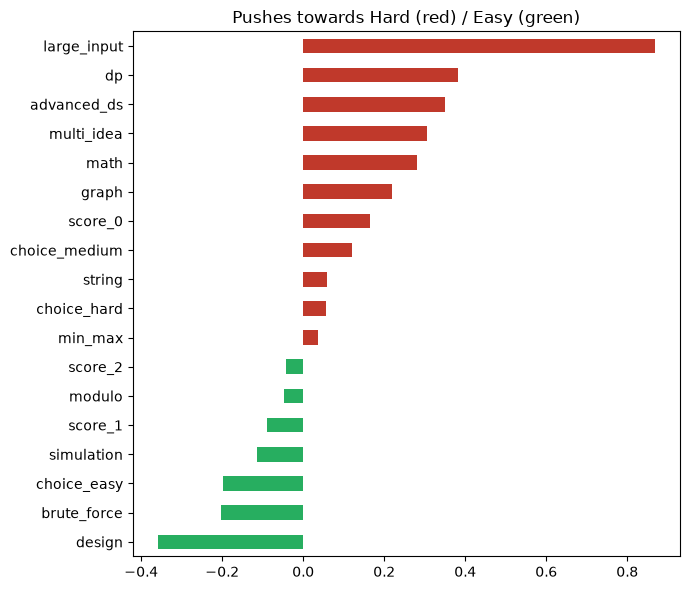

label,Easy,Hard,Medium
dp,0.43,0.61,0.55
graph,0.07,0.16,0.12
advanced_ds,0.26,0.44,0.38
brute_force,0.31,0.38,0.37
large_input,0.13,0.27,0.25
math,0.48,0.64,0.59
modulo,0.20,0.28,0.26
multi_idea,0.43,0.63,0.56
simulation,0.41,0.51,0.48
min_max,0.21,0.27,0.26


In [9]:
def lr_cv(X_tr, y_tr_):
    grid = GridSearchCV(
        make_pipeline(StandardScaler(), LogisticRegression(class_weight=CW, max_iter=5000)),
        {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10]},
        scoring="neg_log_loss", cv=StratifiedKFold(CFG.cv_folds, shuffle=True, random_state=SEED))
    return grid.fit(X_tr, y_tr_)

X_sig = np.hstack([S, P_choice, P_score])
sig_names = list(SIGNALS) + [f"choice_{k}" for k in DIFF_OPTS] + [f"score_{i}" for i in range(3)]
m_sig = lr_cv(X_sig[tr_idx], y_tr)
report("Laya signals + LR", y_te, proba=m_sig.predict_proba(X_sig[te_idx]))

# which signals matter? coefficient of Hard minus Easy (on standardised features)
coef = m_sig.best_estimator_[-1].coef_
imp = pd.Series(coef[2] - coef[0], index=sig_names).sort_values()
ax = imp.plot.barh(figsize=(7, 6), color=np.where(imp > 0, "#c0392b", "#27ae60"))
ax.set_title("Pushes towards Hard (red) / Easy (green)"); plt.tight_layout()
plt.savefig(FIG / "laya_signal_weights.png", dpi=CFG.fig_dpi); plt.show()

# sanity check: signal means per true class
pd.DataFrame(S, columns=list(SIGNALS)).groupby(df.label.map(dict(enumerate(LABELS)))).mean().T.round(2)

## 7. Laya encoder embeddings → linear probe

A linear probe: ModernBERT-large as Laya fine-tuned it, mean-pooled over the last layer, then logistic
regression on top. Here we embed the
**full** fixed text (up to 512 tokens), not the compact state.

In [10]:
emb_path = OUT / "laya_embeddings.npy"
if emb_path.exists() and len(np.load(emb_path)) == len(df):
    E = np.load(emb_path)
else:
    embed = laya.embed_fn_from_agent(agent, max_length=CFG.max_tokens, batch_size=8)
    E = np.vstack([embed(df.text.values[i:i + 64].tolist()) for i in tqdm(range(0, len(df), 64))])
    np.save(emb_path, E)

m_emb = lr_cv(E[tr_idx], y_tr)
report("Laya embeddings + LR", y_te, proba=m_emb.predict_proba(E[te_idx]))

X_both = np.hstack([E, X_sig])
m_both = lr_cv(X_both[tr_idx], y_tr)
P_both = m_both.predict_proba(X_both[te_idx])
report("Laya embeddings + signals + LR", y_te, proba=P_both)

100%|██████████| 37/37 [07:28<00:00, 12.13s/it]


acc               0.493671
macro_f1          0.494316
f1_95ci     [0.447, 0.538]
qwk               0.397711
log_loss          0.980351
brier             0.598699
ece               0.043268
Name: Laya embeddings + signals + LR, dtype: object

## 8. Summary

In [11]:
table = pd.DataFrame(RESULTS).T
table.to_csv(OUT / "results.csv")
table.style.format(precision=3, na_rep="–")

,acc,macro_f1,f1_95ci,qwk,log_loss,brier,ece
majority class,0.511,0.225,"[0.212, 0.237]",0.000,–,–,–
TF-IDF + LinearSVC (old cleaning),0.551,0.484,"[0.436, 0.531]",0.377,–,–,–
TF-IDF + LinearSVC (config cleaning),0.544,0.477,"[0.431, 0.524]",0.362,–,–,–
Laya zero-shot choice,0.468,0.300,"[0.261, 0.338]",0.097,1.048,0.635,0.064
Laya zero-shot score (argmax),0.462,0.311,"[0.271, 0.350]",0.135,1.089,0.657,0.092
Laya choice + temp/bias calibration,0.508,0.225,"[0.211, 0.238]",-0.009,1.031,0.622,0.065
Laya score + temp/bias calibration,0.511,0.225,"[0.213, 0.238]",0.000,1.030,0.619,0.032
Laya signals + LR,0.420,0.416,"[0.368, 0.461]",0.271,1.017,0.626,0.075
Laya embeddings + LR,0.475,0.476,"[0.428, 0.519]",0.373,0.990,0.604,0.054
Laya embeddings + signals + LR,0.494,0.494,"[0.447, 0.538]",0.398,0.980,0.599,0.043


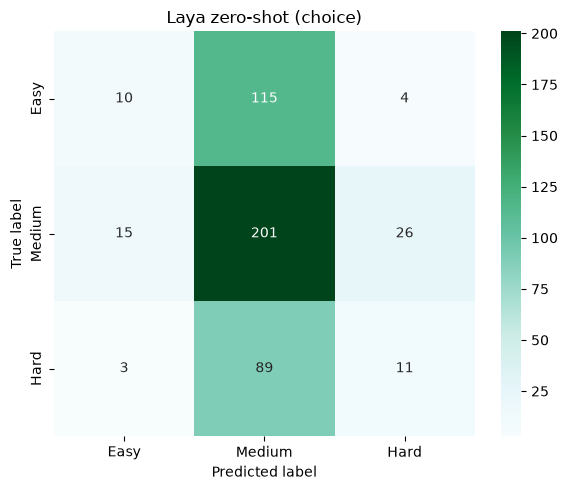

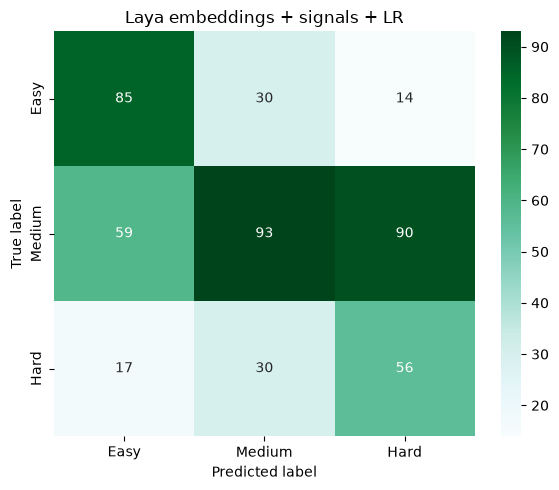

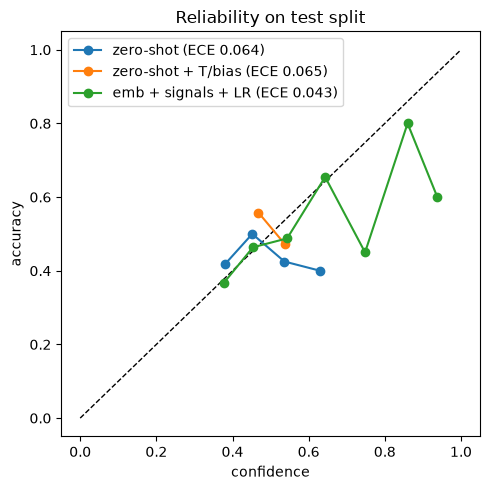

In [12]:
def plot_cm(y_true, pred, title, fname):
    cm = confusion_matrix(y_true, pred)          # rows = true, columns = predicted
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", xticklabels=LABELS, yticklabels=LABELS)
    plt.ylabel("True label"); plt.xlabel("Predicted label"); plt.title(title); plt.tight_layout()
    plt.savefig(FIG / fname, dpi=CFG.fig_dpi); plt.show()

plot_cm(y_te, P_choice[te_idx].argmax(1), "Laya zero-shot (choice)", "laya_zero_shot.png")
plot_cm(y_te, P_both.argmax(1), "Laya embeddings + signals + LR", "laya_probe.png")

# reliability diagram: is "80% confident" right 80% of the time?
plt.figure(figsize=(5, 5)); plt.plot([0, 1], [0, 1], "k--", lw=1)
for P, name in [(P_choice[te_idx], "zero-shot"), (P_choice_cal[te_idx], "zero-shot + T/bias"), (P_both, "emb + signals + LR")]:
    conf, corr = P.max(1), (P.argmax(1) == y_te)
    bins = np.clip((conf * 10).astype(int), 0, 9)
    xs = [conf[bins == b].mean() for b in range(10) if (bins == b).sum() >= 5]
    ys = [corr[bins == b].mean() for b in range(10) if (bins == b).sum() >= 5]
    plt.plot(xs, ys, "o-", label=f"{name} (ECE {ece(P, y_te):.3f})")
plt.xlabel("confidence"); plt.ylabel("accuracy"); plt.legend(); plt.title("Reliability on test split")
plt.tight_layout(); plt.savefig(FIG / "laya_reliability.png", dpi=CFG.fig_dpi); plt.show()

In [13]:
# One MLflow run with everything above: named "laya-<checkpoint>-s<seed>", experiment ".../laya"
with start_run("laya", CFG.laya_model.rstrip("/").split("/")[-1], job_type="eval", config={
        "laya_model": CFG.laya_model, "n_questions": len(QUESTIONS), "questions": QUESTIONS}) as run:
    log_table(run, "results", table.reset_index().rename(columns={"index": "model"}))
    for name, r in RESULTS.items():
        run.summary.update({f"{name}/{k}": v for k, v in r.items() if not isinstance(v, str)})
    log_classification(run, y_te, P_both.argmax(1), prefix="test/embeddings+signals")
    for f in ["laya_zero_shot", "laya_probe", "laya_reliability", "laya_signal_weights"]:
        log_image(run, f"figures/{f}", FIG / f"{f}.png")

test/embeddings+signals: accuracy 0.494, macro_f1 0.494, qwk 0.398


## Next step: fine-tune Laya itself

The model card is explicit that the 0.766 on its own benchmark came from fine-tuning the checkpoint on that
benchmark's training split. The natural follow-up is to train the decision head (and possibly the last encoder
layers) on our train split with the `difficulty` choice question as the target, keeping the same split and table.